In [4]:
# ==============================================================================
# CELL 1: IMPORT LIBRARIES & LOAD DATASET
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set chart styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Exact file name
file_name = "E-commerce Customer Behavior - Sheet1 (1).csv"

# Load dataset
df = pd.read_csv(file_name)

print(f"File '{file_name}' loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns.\n")
display(df.head())

File 'E-commerce Customer Behavior - Sheet1 (1).csv' loaded successfully: 350 rows, 11 columns.



,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [5]:
# ==============================================================================
# CELL 2: INSPECT STRUCTURE & HANDLE MISSING VALUES
# ==============================================================================
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Impute categorical missing values (e.g., in Satisfaction Level) with the mode
if df['Satisfaction Level'].isnull().sum() > 0:
    mode_val = df['Satisfaction Level'].mode()[0]
    df['Satisfaction Level'] = df['Satisfaction Level'].fillna(mode_val)
    print(f"\nImputed missing 'Satisfaction Level' with mode: '{mode_val}'")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None

--- Missing Values Count ---
Customer ID                 0
Gender                

In [6]:
# ==============================================================================
# CELL 3: DESCRIPTIVE STATISTICS & METRICS
# ==============================================================================
# Calculate Average Purchase Value per item
df['Avg_Purchase_Value'] = df['Total Spend'] / df['Items Purchased']
print("--- Key E-Commerce Metrics ---")
print(f"• Average Purchase Value (per item)  : ${df['Avg_Purchase_Value'].mean():.2f}")
print(f"• Average Purchase Frequency (Items) : {df['Items Purchased'].mean():.1f} items")
print(f"• Average Total Spend (CLV)          : ${df['Total Spend'].mean():.2f}")
print(f"• Average Recency (Days Dormant)     : {df['Days Since Last Purchase'].mean():.1f} days\n")
print("--- Statistical Summary ---")
display(df[['Total Spend', 'Items Purchased', 'Days Since Last Purchase', 'Avg_Purchase_Value']].describe().round(2))

--- Key E-Commerce Metrics ---
• Average Purchase Value (per item)  : $65.23
• Average Purchase Frequency (Items) : 12.6 items
• Average Total Spend (CLV)          : $845.38
• Average Recency (Days Dormant)     : 26.6 days

--- Statistical Summary ---


,Total Spend,Items Purchased,Days Since Last Purchase,Avg_Purchase_Value
count,350.00,350.00,350.00,350.00
mean,845.38,12.60,26.59,65.23
std,362.06,4.16,13.44,9.00
min,410.80,7.00,9.00,49.52
25%,502.00,9.00,15.00,57.37
50%,775.20,12.00,23.00,67.03
75%,1160.60,15.00,38.00,73.03
max,1520.10,21.00,63.00,83.59


In [14]:
# ==============================================================================
# CELL 4: FEATURE SELECTION & STANDARDIZATION
# ==============================================================================

# 3 Key RFM Behavioral Features
features = ['Days Since Last Purchase', 'Items Purchased', 'Total Spend']

X = df[features]

# Display selected features
print("Selected RFM Behavioral Features:")
display(X.head())

# Standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected (Recency, Frequency, Monetary) and standardized successfully.")

Selected RFM Behavioral Features:


,Days Since Last Purchase,Items Purchased,Total Spend
0,25,14,1120.20
1,18,11,780.50
2,42,9,510.75
3,12,19,1480.30
4,55,13,720.40


Features selected (Recency, Frequency, Monetary) and standardized successfully.


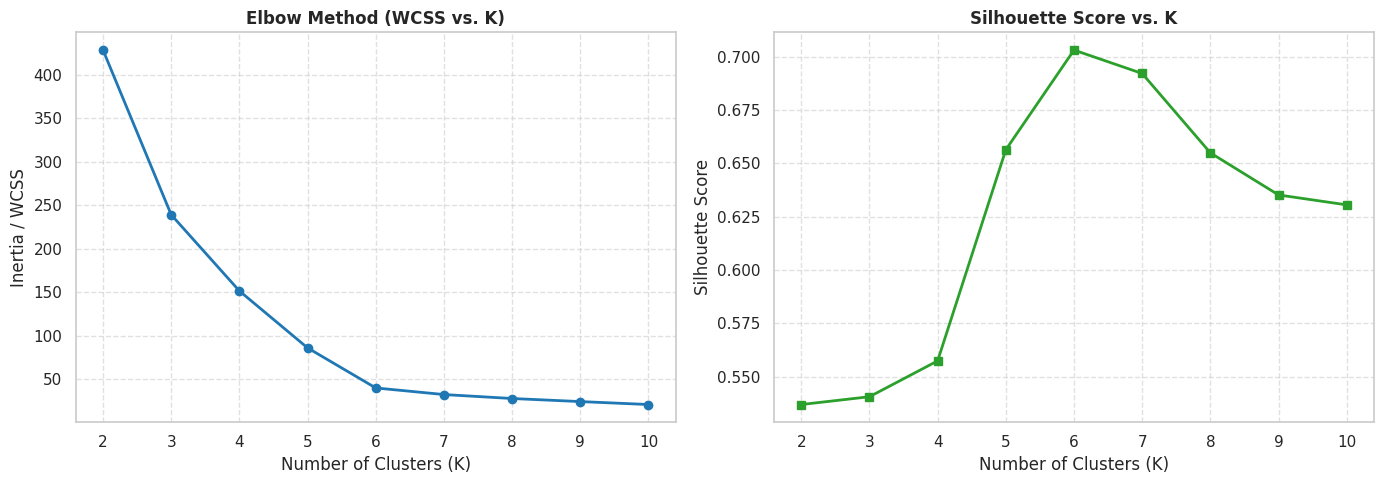

Optimal number of clusters chosen: K = 3


In [8]:
# ==============================================================================
# CELL 5: ELBOW METHOD & SILHOUETTE SCORE
# ==============================================================================
wcss = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(k_range, wcss, marker='o', color='#1f77b4', linewidth=2)
ax1.set_title('Elbow Method (WCSS vs. K)', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia / WCSS')
ax1.grid(True, linestyle='--', alpha=0.6)

# Silhouette Score Curve
ax2.plot(k_range, silhouette_vals, marker='s', color='#2ca02c', linewidth=2)
ax2.set_title('Silhouette Score vs. K', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Optimal number of clusters chosen: K = 3")

In [15]:
# ==============================================================================
# CELL 6: FIT OPTIMAL K-MEANS MODEL (K=3)
# ==============================================================================
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering completed. Assigned clusters:", sorted(df['Cluster'].unique()))

Clustering completed. Assigned clusters: [np.int32(0), np.int32(1), np.int32(2)]


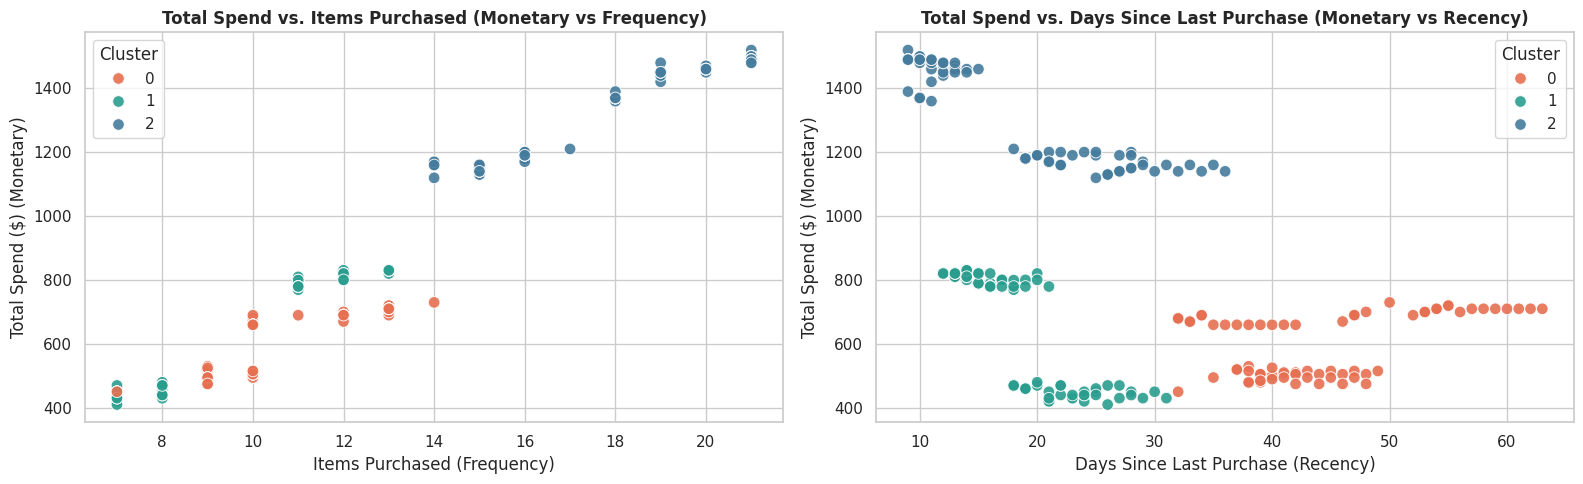

In [10]:
# ==============================================================================
# CELL 7: SCATTER PLOTS (2 FEATURE COMBINATIONS)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#e76f51', '#2a9d8f', '#457b9d']

# Combination 1: Total Spend vs Items Purchased (Monetary vs Frequency)
sns.scatterplot(
    data=df, x='Items Purchased', y='Total Spend', hue='Cluster',
    palette=colors, s=70, alpha=0.9, ax=axes[0]
)
axes[0].set_title('Total Spend vs. Items Purchased (Monetary vs Frequency)', fontweight='bold')
axes[0].set_xlabel('Items Purchased (Frequency)')
axes[0].set_ylabel('Total Spend ($) (Monetary)')

# Combination 2: Total Spend vs Days Since Last Purchase (Monetary vs Recency)
sns.scatterplot(
    data=df, x='Days Since Last Purchase', y='Total Spend', hue='Cluster',
    palette=colors, s=70, alpha=0.9, ax=axes[1]
)
axes[1].set_title('Total Spend vs. Days Since Last Purchase (Monetary vs Recency)', fontweight='bold')
axes[1].set_xlabel('Days Since Last Purchase (Recency)')
axes[1].set_ylabel('Total Spend ($) (Monetary)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_698/2652075708.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=colors)


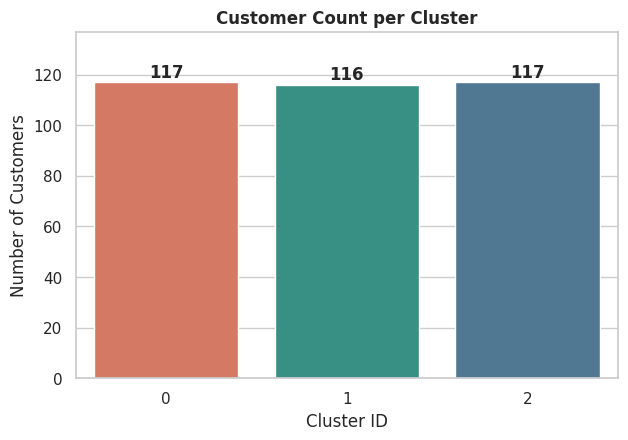

In [11]:
# ==============================================================================
# CELL 8: BAR CHART - CUSTOMER DISTRIBUTION PER CLUSTER
# ==============================================================================
plt.figure(figsize=(7, 4.5))
cluster_counts = df['Cluster'].value_counts().sort_index()

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=colors)
plt.title('Customer Count per Cluster', fontweight='bold')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')

for i, count in enumerate(cluster_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.ylim(0, max(cluster_counts.values) + 20)
plt.show()

In [12]:
# ==============================================================================
# CELL 9: CLUSTER PROFILING SUMMARY TABLE
# ==============================================================================
profile = df.groupby('Cluster').agg({
    'Days Since Last Purchase': 'mean',
    'Items Purchased': 'mean',
    'Total Spend': 'mean',
    'Avg_Purchase_Value': 'mean',
    'Average Rating': 'mean',
    'Age': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Count'}).round(2)

def label_segment(spend):
    if spend > 1100:
        return 'VIP / High-Value Champions'
    elif spend > 650:
        return 'Loyal Regulars'
    else:
        return 'At-Risk / Low-Engagement'

profile['Segment Name'] = [label_segment(s) for s in profile['Total Spend']]
display(profile)

,Days Since Last Purchase,Items Purchased,Total Spend,Avg_Purchase_Value,Average Rating,Age,Count,Segment Name
Cluster,,,,,,,,
0,42.89,10.50,593.90,56.69,3.69,35.50,117,At-Risk / Low-Engagement
1,18.87,9.66,629.25,64.21,3.69,35.39,116,At-Risk / Low-Engagement
2,17.94,17.62,1311.14,74.78,4.68,29.92,117,VIP / High-Value Champions


In [13]:
# ==============================================================================
# CELL 10: ACTIONABLE MARKETING RECOMMENDATIONS
# ==============================================================================
print("""
====================================================================================
               CUSTOMER SEGMENTATION: MARKETING ACTION STRATEGY
====================================================================================

1. VIP / HIGH-VALUE CHAMPIONS (High Spend, High Frequency, Low Recency)
   • Profile: Gold membership holders, shop frequently (< 20 days ago), spend > $1,200+.
   • Recommended Actions:
     - Provide VIP early access to product launches and sales.
     - Offer premium loyalty rewards and complimentary priority shipping.
     - Launch VIP referral programs to acquire similar high-value customers.

2. LOYAL REGULARS (Moderate Spend, Steady Frequency, Average Recency)
   • Profile: Silver membership holders, steady repeat purchases, spend around $700-$850.
   • Recommended Actions:
     - Deploy personalized product recommendations and bundle discounts to increase basket size.
     - Implement tier-upgrade incentives (e.g., "Spend $150 more to unlock Gold status").
     - Offer point multipliers on selected categories.

3. AT-RISK / LOW-ENGAGEMENT SHOPPERS (Low Spend, Low Frequency, High Recency)
   • Profile: Bronze members with 35-60+ days dormancy, low item counts, lower satisfaction.
   • Recommended Actions:
     - Send automated re-engagement win-back emails with a 20% discount coupon.
     - Conduct short feedback surveys to address dissatisfaction pain points.
     - Offer low-barrier promotions such as free shipping without a minimum order.
====================================================================================
""")


               CUSTOMER SEGMENTATION: MARKETING ACTION STRATEGY

1. VIP / HIGH-VALUE CHAMPIONS (High Spend, High Frequency, Low Recency)
   • Profile: Gold membership holders, shop frequently (< 20 days ago), spend > $1,200+.
   • Recommended Actions:
     - Provide VIP early access to product launches and sales.
     - Offer premium loyalty rewards and complimentary priority shipping.
     - Launch VIP referral programs to acquire similar high-value customers.

2. LOYAL REGULARS (Moderate Spend, Steady Frequency, Average Recency)
   • Profile: Silver membership holders, steady repeat purchases, spend around $700-$850.
   • Recommended Actions:
     - Deploy personalized product recommendations and bundle discounts to increase basket size.
     - Implement tier-upgrade incentives (e.g., "Spend $150 more to unlock Gold status").
     - Offer point multipliers on selected categories.

3. AT-RISK / LOW-ENGAGEMENT SHOPPERS (Low Spend, Low Frequency, High Recency)
   • Profile: Bronze memb